# Moroccanization

## Overview

This notebook presents the transformation of the original Brazilian Olist dataset into **ChriLy**, a Moroccan e-commerce dataset.

The localization pipeline was implemented in `src/moroccanization.py`. This notebook documents and visualizes the applied transformations without modifying the data.

The main objectives are:

- Localize the dataset to the Moroccan market
- Modernize the timeline
- Adapt payment methods and logistics
- Convert prices from BRL to MAD
- Create additional business attributes
- Compare the original and localized datasets

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

RAW_PATH = Path("../data/raw")
MOROCCO_PATH = Path("../data/morocco")

In [2]:
raw_customers = pd.read_csv(
    RAW_PATH / "olist_customers_dataset.csv"
)

raw_orders = pd.read_csv(
    RAW_PATH / "olist_orders_dataset.csv"
)

raw_order_items = pd.read_csv(
    RAW_PATH / "olist_order_items_dataset.csv"
)

raw_payments = pd.read_csv(
    RAW_PATH / "olist_order_payments_dataset.csv")

In [3]:
chrily_customers = pd.read_csv(
    MOROCCO_PATH / "chrily_customers.csv"
)

chrily_orders = pd.read_csv(
    MOROCCO_PATH / "chrily_orders.csv"
)

chrily_order_items = pd.read_csv(
    MOROCCO_PATH / "chrily_order_items.csv"
)

chrily_payments = pd.read_csv(
    MOROCCO_PATH / "chrily_order_payments.csv"
)

The localization process preserved the original dataset size while adapting the data to the Moroccan context

In [4]:
overview = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Orders",
        "Order Items",
        "Payments"
    ],

    "Original":[
        len(raw_customers),
        len(raw_orders),
        len(raw_order_items),
        len(raw_payments)
    ],

    "Localized":[
        len(chrily_customers),
        len(chrily_orders),
        len(chrily_order_items),
        len(chrily_payments)
    ]

})

overview

,Dataset,Original,Localized
0,Customers,99441,99441
1,Orders,99441,99441
2,Order Items,112650,112650
3,Payments,103886,103886


# Currency Conversion


In [5]:
comparison = pd.DataFrame({

    "Original (BRL)": raw_order_items["price"].head(10),

    "Localized (MAD)": chrily_order_items["price"].head(10)

})

comparison

,Original (BRL),Localized (MAD)
0,58.90,107.79
1,239.90,439.02
2,199.00,364.17
3,12.99,23.77
4,199.90,365.82
5,21.90,40.08
6,19.90,36.42
7,810.00,1482.30
8,145.95,267.09
9,53.99,98.80


The distribution keeps exactly the same shape because only the currency unit changed.

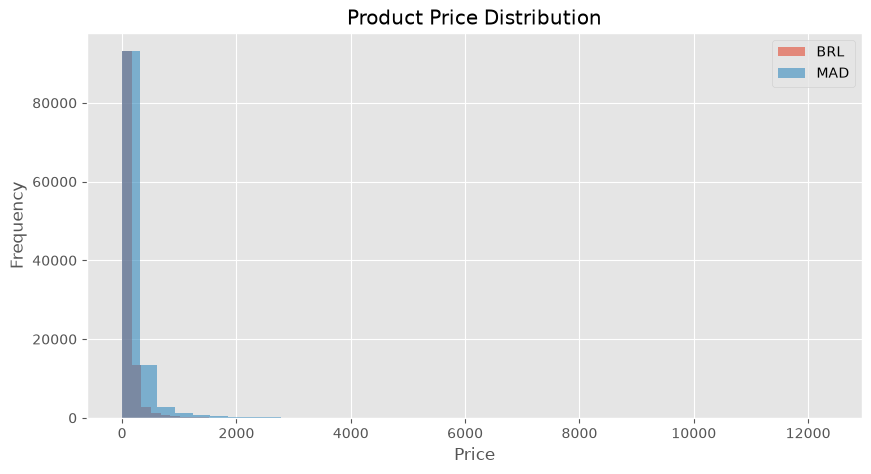

In [6]:
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(
    raw_order_items["price"],
    bins=40,
    alpha=.6,
    label="BRL"
)

ax.hist(
    chrily_order_items["price"],
    bins=40,
    alpha=.6,
    label="MAD"
)

ax.set_title("Product Price Distribution")

ax.set_xlabel("Price")

ax.set_ylabel("Frequency")

ax.legend()

plt.show()

# Payment Methods


In [7]:
payment_compare = pd.DataFrame({

    "Original":

    raw_payments["payment_type"]

    .value_counts(),

    "Localized":

    chrily_payments["payment_type"]

    .value_counts()

}).fillna(0)

payment_compare

,Original,Localized
payment_type,,
Bank Card,0.0,76795.0
Bank Transfer,0.0,1529.0
Cash on Delivery,0.0,19784.0
Gift Voucher,0.0,5775.0
Other,0.0,3.0
boleto,19784.0,0.0
credit_card,76795.0,0.0
debit_card,1529.0,0.0
not_defined,3.0,0.0


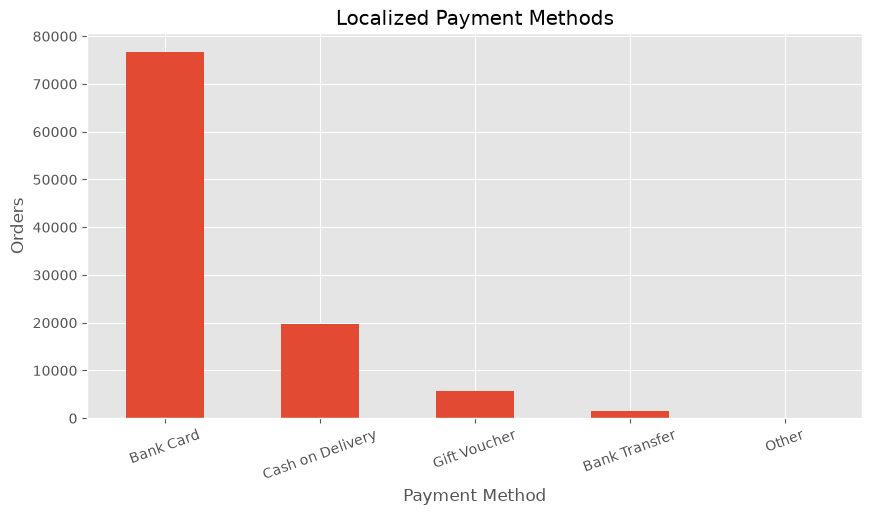

In [8]:
fig, ax = plt.subplots(figsize=(10,5))

chrily_payments["payment_type"] \
.value_counts() \
.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Localized Payment Methods")

ax.set_xlabel("Payment Method")

ax.set_ylabel("Orders")

plt.xticks(rotation=20)

plt.show()

# Geography Localization

In [9]:
customer_geo = pd.DataFrame({

    "Original City":

    raw_customers["customer_city"].head(15),

    "Localized City":

    chrily_customers["customer_city"].head(15),

    "Original State":

    raw_customers["customer_state"].head(15),

    "Localized Region":

    chrily_customers["customer_state"].head(15)

})

customer_geo

,Original City,Localized City,Original State,Localized Region
0,franca,Mohammedia,SP,Casablanca-Settat
1,sao bernardo do campo,Casablanca,SP,Casablanca-Settat
2,sao paulo,Settat,SP,Casablanca-Settat
3,mogi das cruzes,Casablanca,SP,Casablanca-Settat
4,campinas,Settat,SP,Casablanca-Settat
5,jaragua do sul,Agadir,SC,Souss-Massa
6,sao paulo,Settat,SP,Casablanca-Settat
7,timoteo,Tangier,MG,Tanger-Tétouan-Al Hoceïma
8,curitiba,Taza,PR,Fès-Meknès
9,belo horizonte,Larache,MG,Tanger-Tétouan-Al Hoceïma


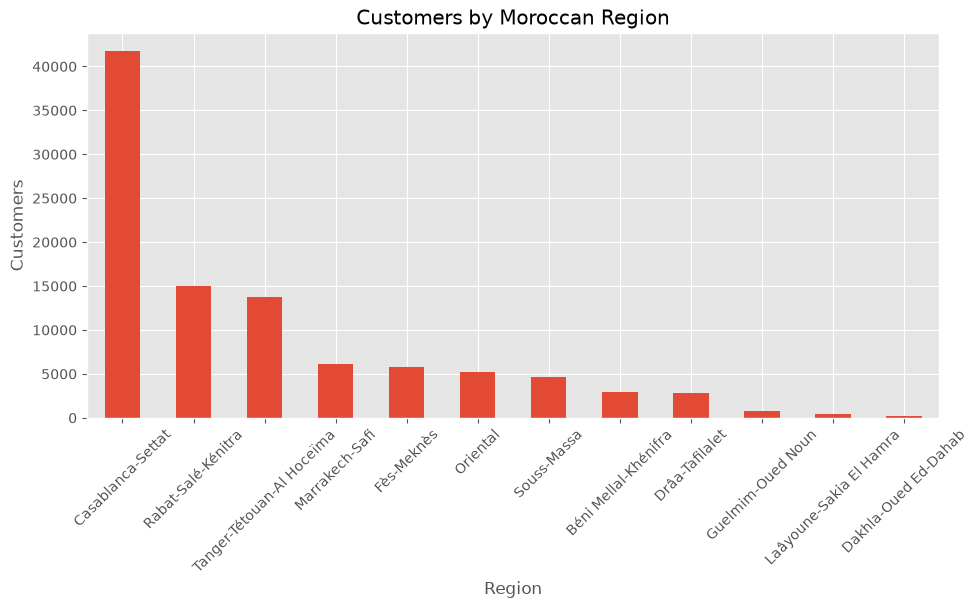

In [10]:
fig, ax = plt.subplots(figsize=(11,5))

chrily_customers["customer_state"] \
.value_counts() \
.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Customers by Moroccan Region")

ax.set_xlabel("Region")

ax.set_ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

# Timeline Modernization
To make the dataset relevant for modern analytics, all timestamps were shifted forward by **8 years**

In [11]:
raw_orders["order_purchase_timestamp"] = pd.to_datetime(
    raw_orders["order_purchase_timestamp"]
)

chrily_orders["order_purchase_timestamp"] = pd.to_datetime(
    chrily_orders["order_purchase_timestamp"]
)

date_comparison = pd.DataFrame({

    "Dataset": [
        "Original",
        "ChriLy"
    ],

    "Start Date": [
        raw_orders["order_purchase_timestamp"].min().date(),
        chrily_orders["order_purchase_timestamp"].min().date()
    ],

    "End Date": [
        raw_orders["order_purchase_timestamp"].max().date(),
        chrily_orders["order_purchase_timestamp"].max().date()
    ]

})

date_comparison

,Dataset,Start Date,End Date
0,Original,2016-09-04,2018-10-17
1,ChriLy,2024-09-04,2026-10-17


The monthly purchasing behavior remains identical.

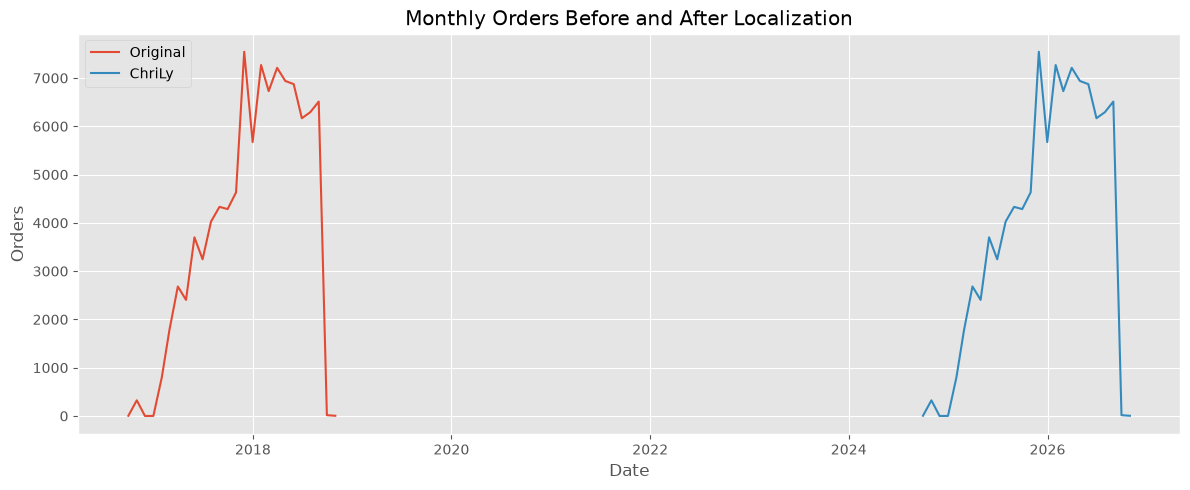

In [12]:
raw_monthly = (
    raw_orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

chrily_monthly = (
    chrily_orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12,5))

plt.plot(
    raw_monthly.index,
    raw_monthly.values,
    label="Original"
)

plt.plot(
    chrily_monthly.index,
    chrily_monthly.values,
    label="ChriLy"
)

plt.title("Monthly Orders Before and After Localization")

plt.xlabel("Date")

plt.ylabel("Orders")

plt.legend()

plt.tight_layout()

plt.show()

# Logistics Localization
Each seller was assigned a preferred carrier representative of the Moroccan delivery ecosystem.

In [13]:
carrier_counts = (
    chrily_order_items["carrier_name"]
    .value_counts()
)

carrier_counts

carrier_name
Amana              44649
Aramex Morocco     28262
Speedaf Morocco    15098
Jumia Logistics    14463
Catoni             10178
Name: count, dtype: int64

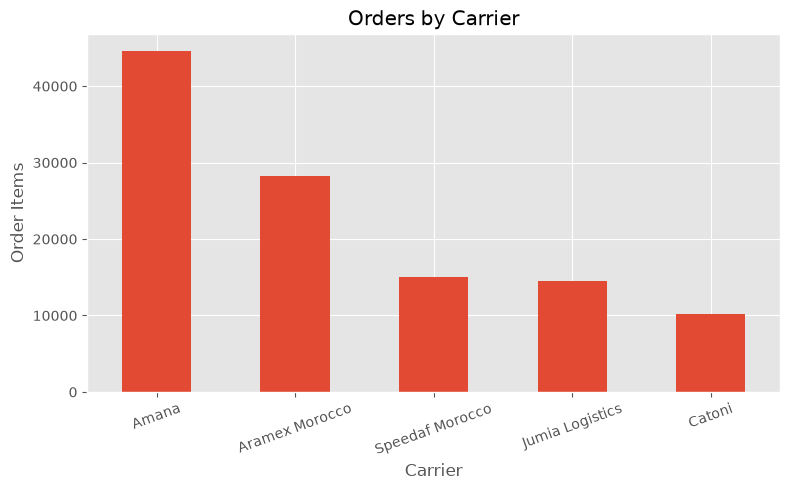

In [14]:
plt.figure(figsize=(8,5))

carrier_counts.plot(kind="bar")

plt.title("Orders by Carrier")

plt.xlabel("Carrier")

plt.ylabel("Order Items")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Tracking Numbers

Each localized shipment receives a synthetic tracking number matching the assigned logistics provider.

These identifiers simulate real shipment tracking systems commonly used by Moroccan carriers.

In [15]:
chrily_order_items[
    [
        "carrier_name",
        "tracking_number"
    ]
].sample(10, random_state=42)

,carrier_name,tracking_number
107777,Amana,AMN-2025-71632060
2391,Speedaf Morocco,CHR-2024-67174591
77829,Aramex Morocco,CHR-2025-82651754
99819,Amana,AMN-2024-99075928
41297,Amana,AMN-2025-17027123
111433,Amana,AMN-2026-42621751
18924,Amana,AMN-2026-32002238
102447,Catoni,CAT-2026-40649543
33507,Amana,AMN-2024-14932707
49559,Catoni,CAT-2024-12251689


# Customer Contact Information
Synthetic Moroccan mobile numbers were generated for every customer using the **+212** country code.

In [16]:
chrily_customers[
    [
        "customer_phone"
    ]
].sample(10, random_state=42)

,customer_phone
52263,212737111611
46645,212653593465
37546,212723802980
94756,212612211155
14771,212763343536
36263,212679893181
98556,212797714985
23747,212734355093
50315,212776270091
6501,212681266848


# WhatsApp Order Confirmation

Cash-on-delivery businesses in Morocco frequently confirm orders through WhatsApp before shipment.

The localized dataset includes a synthetic **whatsapp_confirmed** feature to reflect this operational practice.# WhatsApp Order Confirmation

In [19]:
pd.crosstab(
    chrily_orders["order_status"],
    chrily_orders["whatsapp_confirmed"],
    normalize="index"
).round(2) * 100

whatsapp_confirmed,False,True
order_status,,
approved,100.0,0.0
canceled,76.0,24.0
created,100.0,0.0
delivered,5.0,95.0
invoiced,100.0,0.0
processing,28.0,72.0
shipped,11.0,89.0
unavailable,100.0,0.0


<Figure size 800x500 with 0 Axes>

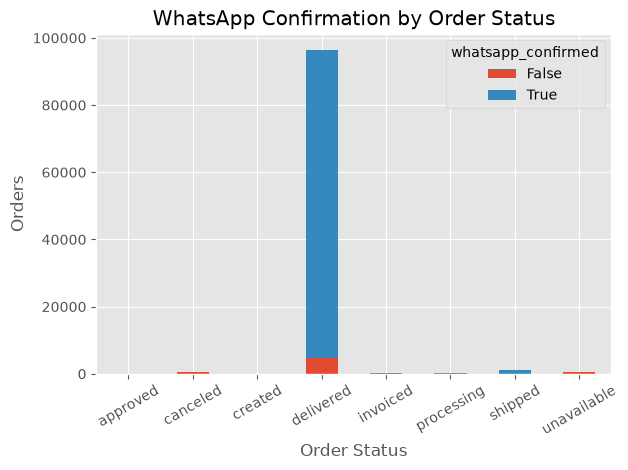

In [20]:
whatsapp_status = pd.crosstab(
    chrily_orders["order_status"],
    chrily_orders["whatsapp_confirmed"]
)

plt.figure(figsize=(8,5))

whatsapp_status.plot(
    kind="bar",
    stacked=True
)

plt.title("WhatsApp Confirmation by Order Status")

plt.xlabel("Order Status")

plt.ylabel("Orders")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

# Moroccanization Summary

The localization pipeline successfully transformed the Brazilian Olist dataset into **ChriLy**, a synthetic Moroccan e-commerce dataset while preserving the original business relationships and analytical value.

The pipeline introduced the following transformations:

- Currency conversion from BRL to MAD
- Moroccan regions, cities, postal codes and coordinates
- Localized product categories
- Moroccan payment methods
- Moroccan logistics providers
- Shipment tracking numbers
- Customer phone numbers
- WhatsApp confirmation
- Cancellation reasons
- Modernized timeline (2024–2026)
- Holiday enrichment

In [23]:
transformation_summary = pd.DataFrame({

    "Dimension": [

        "Marketplace",
        "Country",
        "Currency",
        "Timeline",
        "Customer Geography",
        "Seller Geography",
        "Payment Methods",
        "Product Categories",
        "Logistics Providers",
        "Shipment Tracking",
        "Customer Phone Numbers",
        "WhatsApp Confirmation",
        "Cancellation Reasons"

    ],

    "Original Dataset": [

        "Olist",
        "Brazil",
        "Brazilian Real (BRL)",
        "2016–2018",
        "Brazilian",
        "Brazilian",
        "Brazilian payment methods",
        "Portuguese",
        "Brazilian logistics",
        "Not Available",
        "Not Available",
        "Not Available",
        "Not Available"

    ],

    "Localized Dataset": [

        "ChriLy",
        "Morocco",
        "Moroccan Dirham (MAD)",
        "2024–2026",
        "Moroccan",
        "Moroccan",
        "Moroccan payment methods",
        "French",
        "Moroccan carriers",
        "Generated",
        "Generated (+212)",
        "Generated",
        "Generated"

    ]

})

transformation_summary

,Dimension,Original Dataset,Localized Dataset
0,Marketplace,Olist,ChriLy
1,Country,Brazil,Morocco
2,Currency,Brazilian Real (BRL),Moroccan Dirham (MAD)
3,Timeline,2016–2018,2024–2026
4,Customer Geography,Brazilian,Moroccan
5,Seller Geography,Brazilian,Moroccan
6,Payment Methods,Brazilian payment methods,Moroccan payment methods
7,Product Categories,Portuguese,French
8,Logistics Providers,Brazilian logistics,Moroccan carriers
9,Shipment Tracking,Not Available,Generated
